In [63]:

from langchain_groq import ChatGroq
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from dotenv import load_dotenv
from langgraph.checkpoint.postgres import PostgresSaver
import os   
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore
from langchain_core.runnables import RunnableConfig
from pydantic import BaseModel,Field
from typing import List

load_dotenv(override=True)
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
print(f"API Key Loaded: {bool(os.getenv('GROQ_API_KEY'))}")
# Initialize LLM with Groq API for chat responses
llm = ChatGroq(model="openai/gpt-oss-120b")
print("LLM initialized successfully!")

API Key Loaded: True
LLM initialized successfully!


In [64]:
# Create in-memory store with hierarchical namespace for user data persistence
store = InMemoryStore()
user_id = "u1"

# Define namespace as tuple: (category, user_id, subcategory)
user_details=("user", user_id, "details")

# Store user profile information in key-value format within namespace
store.put(user_details, "profile_1", {"data": "Name : Basanti "})
store.put(user_details, "profile_2", {"data": "Age : 30"})
store.put(user_details, "profile_3", {"data": "He is a AI + Backend Engineer"})


In [65]:
# Personalized system prompt that injects user memory context into LLM instructions
SYSTEM_PROMPT_TEMPLATE = """
You are a helpful assistant with memory capabilities. You have access to a memory store that contains information about the user.
You can use the memory store to retrieve information about the user and provide personalized responses.
your goal is to provide relevant,friendly and tailored responses to the user based on the information stored in the memory store.
Memory store contains the following information about the user:

If you know user, uyou response with user name as well.

Avoid generic phrasing and provide specific information based on the user's details. for example instead of "In typescript apps ..."
say "since your project built in typescript, you can use the following code snippet ..."

use personailzation in your responses to make the user feel valued and understood.
-Greeting and transition
-Help or guidance tailored to tools and frameworks the user uses
-follow-up messages that cntinue  from past context
always ensure that personalization is based only on known u user details not assumed.

in the end suggest 3 relevant further operations based on current response and user profile.
The user's memory which may be empty is provided as : {user_Details_content}
"""




In [66]:
def chat_node(state:MessagesState,config:RunnableConfig,*,store:BaseStore):
    usr_id = config["configurable"]["user_id"]

    # Retrieve user details from LTM store to build personalized context
    items = store.search(user_details)
    
    # Format retrieved memory items into readable text for prompt injection
    if items: 
        user_Details_content = "\n".join(f"- {it.value.get('data','')}" for it in items)
    else:
        user_Details_content = "No user details available."

    # Inject user context into system prompt template
    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(user_Details_content=user_Details_content)

    system_msg=SystemMessage(content=system_prompt)
    
    # Call LLM with personalized system prompt + conversation messages
    try:
        response = llm.invoke([system_msg] + state.get("messages", []))
    except Exception as e:
        print(f"API Error: {e}")
        response = SystemMessage(content="API call failed. Using default response.")



    return {"messages":[response]}

Graph compiled successfully!


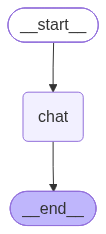

In [67]:
# Build LangGraph state machine with single chat node
builder = StateGraph(MessagesState)
builder.add_node("chat",chat_node)
builder.add_edge(START,"chat")
builder.add_edge("chat",END)

# Compile graph with in-memory store for node access
graph = builder.compile(store=store)
print("Graph compiled successfully!")
graph

In [68]:
# Execute graph with user config and test message
config = {"configurable" : {"user_id":"u1"}}

# Invoke graph - chat_node will access LTM and personalize response
result = graph.invoke(
    {
        "messages":[{"role":"user","content":"explain gen ai in simple terms"}]
    },
    config,
)

# Print LLM response with injected user context
print(result["messages"][-1].content)

**Hey Basanti!** 👋  

Since you’re an AI + Backend Engineer, you already have a good feel for how services talk to each other and how data moves through a system. Think of **generative AI** (Gen AI) as a new kind of service you can call, but instead of returning static data it **creates new content on the fly**—text, code, images, audio, or even whole data structures—based on the patterns it learned during training.

### A quick, backend‑flavored analogy
| Traditional backend endpoint | Generative AI endpoint |
|-----------------------------|------------------------|
| `GET /users/123` → returns stored user record | `POST /generate‑email` → returns a brand‑new email draft that never existed before |
| Data is **retrieved** exactly as stored | Data is **synthesized** from learned knowledge |

In practice:

1. **Training phase** – You feed a massive dataset (e.g., billions of text snippets) into a model. The model learns statistical relationships (like “the word *‘machine’* often follows

In [69]:
store = InMemoryStore()

In [70]:
extractor_llm = ChatGroq(model="openai/gpt-oss-120b",temperature=0)


In [71]:
class MemoryDecision(BaseModel):
    should_write : bool = Field(description="whether to store any memories")
    memories :List[str] = Field(default_factory=list,description="Atomic user memories to store")

In [72]:
memory_extractor = extractor_llm.with_structured_output(MemoryDecision)

In [79]:
import uuid
def remember_only_node(state:MessagesState,config:RunnableConfig , store:BaseStore):
    user_id=config["configurable"]["user_id"]

    namespace = ("user",user_id , "details")
    last_msg = state["messages"][-1].content

    decision:MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(
                content=(
                    "Extract LONG-TERM memories from user's message.\n"
                    "only store stable . user speciic info (identoty . preferences and ongoing projects). \n"
                    "Donot store transient info .\n"
                    "return should_write=false if nothing is worth storing \n "
                    "each memory should be a short atomic sentence."

                )
            ),
            {"role":"user","content":last_msg},

        ]
    )

    #write to store LTM

    if decision.should_write:
        for mem in decision.memories:
            store.put(namespace,str(uuid.uuid4()),{"data":mem})

#IMPORTANT : we are no using memory not evebn responding with the LLM

    return {"messages":[{"role":"assistant","content":"Noted..."}]}

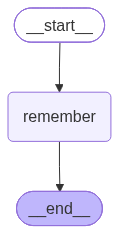

In [80]:
builder = StateGraph(MessagesState)
builder.add_node("remember",remember_only_node)
builder.add_edge(START,"remember")
builder.add_edge("remember",END)

graph = builder.compile(store=store)
graph


In [81]:
#Demo
config = {"configurable": {"user_id":"u1"}}
res = graph.invoke(
    {"messages":[{"role":"user","content":"Hi, my name is vijay pandit"}]},config)

print("Assistant : ",res["messages"][-1].content)

Assistant :  Noted...


In [84]:
#Demo
res = graph.invoke(
    {"messages":[{"role":"user","content":"Hi, I am a senior backend engineer teaching on Youtube and Instagaram"}]},config)

print("Assistant : ",res["messages"][-1].content)

Assistant :  Noted...


In [88]:
items = store.search(("user","u1","details"))
for item in items:
    print(item.value['data'])

User's name is Vijay Pandit.
User's name is Vijay Pandit.
The user is a senior backend engineer.
The user creates teaching content on YouTube.
The user creates teaching content on Instagram.
User is a senior backend engineer.
User creates teaching content on YouTube.
User creates teaching content on Instagram.


#Duplicate memory gets saved , so we have tio implement de-duplication strategy 